# XSEA: X-Set Enrichment Analysis (cf: ABAnnotate)

Gene-set or gene-category enrichment analysis (GSEA or GCSEA) usually refers to analysis frameworks that test if a set of genes that you are interested in (e.g., genes found in a disease-GWAS) are found more often in some given sets of genes (e.g., marker genes of specific neural cell types) than expected under assumption of randomness. This idea was adopted to the field of neuroimaging some time ago already. The method introduced here was significantly inspired by Ben Fulcher's [paper](https://doi.org/10.1038/s41467-021-22862-1) and [matlab code](https://github.com/benfulcher/GeneCategoryEnrichmentAnalysis). 

In 2023, I build a toolbox from Ben Fulcher's code, called [ABAnnotate](https://github.com/LeonDLotter/ABAnnotate). ABAnnotate will not be further developed, but it's functionality is now part of NiSpace.

## The Method

Neuroimaging GSEA most often works on a single input brain map defined by the user and thousands of Allen Human Brain Atlas gene expression maps. The core idea is rather simple: We define some gene sets of interest (e.g., cell type markers). We correlate our input map with all gene expression maps in each gene set. We take the average of these correlations per set as our association measure. We then randomly sample new gene sets from the whole dataset of genes, keeping the size of the gene sets constant, and calculate the average correlation again. These will form the null distribution to which our association measure can be compared.  
As you will see, NiSpace allows two ocre versions of this null test: Sample random gene sets from a larger dataset or don't sample random genes but create null maps of the *input* brain map.

### "XSEA"?

In NiSpace, we do not use the term GSEA, but generalize it to XSEA, which stands for X-Set Enrichment Analysis. We use "X" in the linear-model-sense as "predictor". There was no reason to limit NiSpace's set-enrichment analysis functionality to gene expression data. Instead, the XSEA methods work on any kind of input data that is organized into sets of maps. For example, we can also analyze PET maps (e.g., a serotonin set could consist of 5HT1a, 5HT2a, 5HT4, and 5HT6 maps) or neurosynth meta-analysis term maps that way (e.g., a "sensory" set could consist of maps for "visual", "auditory", and "somatosensory" terms).

## NiSpace vs. ABAnnotate

NiSpace is a much more recent project and has been developed with the goal of flexibility, while still providing a user-friendly interface.  
Especially, the map-based null models are much more advanced than in ABAnnotate, leading to different results. Developments include:

- Flexible null model combinations
- Moran randomization as the default map-based null model
- Enforcing level of bilateral symmetry of the null maps to match the input map
- Extending the set-enrichment method to all types of included reference data
- Allen Brain Atlas mRNA data is for now provided only for genes that showed an average across-donor Spearman's rho of at least 0.2
- Many different parcellations
- Works with MNI, fsaverage, and fsLR input data
- Last but not least: Python as an open-source language with a large community and the likely future of neuroimaging analysis (yes, I know, I'm biased)

The following example is provided as comparison to the [example](https://github.com/LeonDLotter/ABAnnotate/blob/main/example/example_pain.md) in the ABAnnotate repository.

## Imports

In [1]:
# load local nispace, for testing
# COMMENT THIS OUT IF YOU RUN THIS LOCALLY AFTER INSTALLING NISPACE
import sys
sys.path.append("/Users/llotter/projects/nispace/")

# general imports
import matplotlib.pyplot as plt
import pandas as pd

# import imaging functions
from nilearn.image import load_img
from nilearn.plotting import view_img

## Get an input brain map

This is a meta-analytically derived map automatically generated from the "pain" neuroscientific literature via [NeuroQuery](https://neuroquery.org/query?text=pain+).

/Applications/miniforge3/envs/nsp309/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



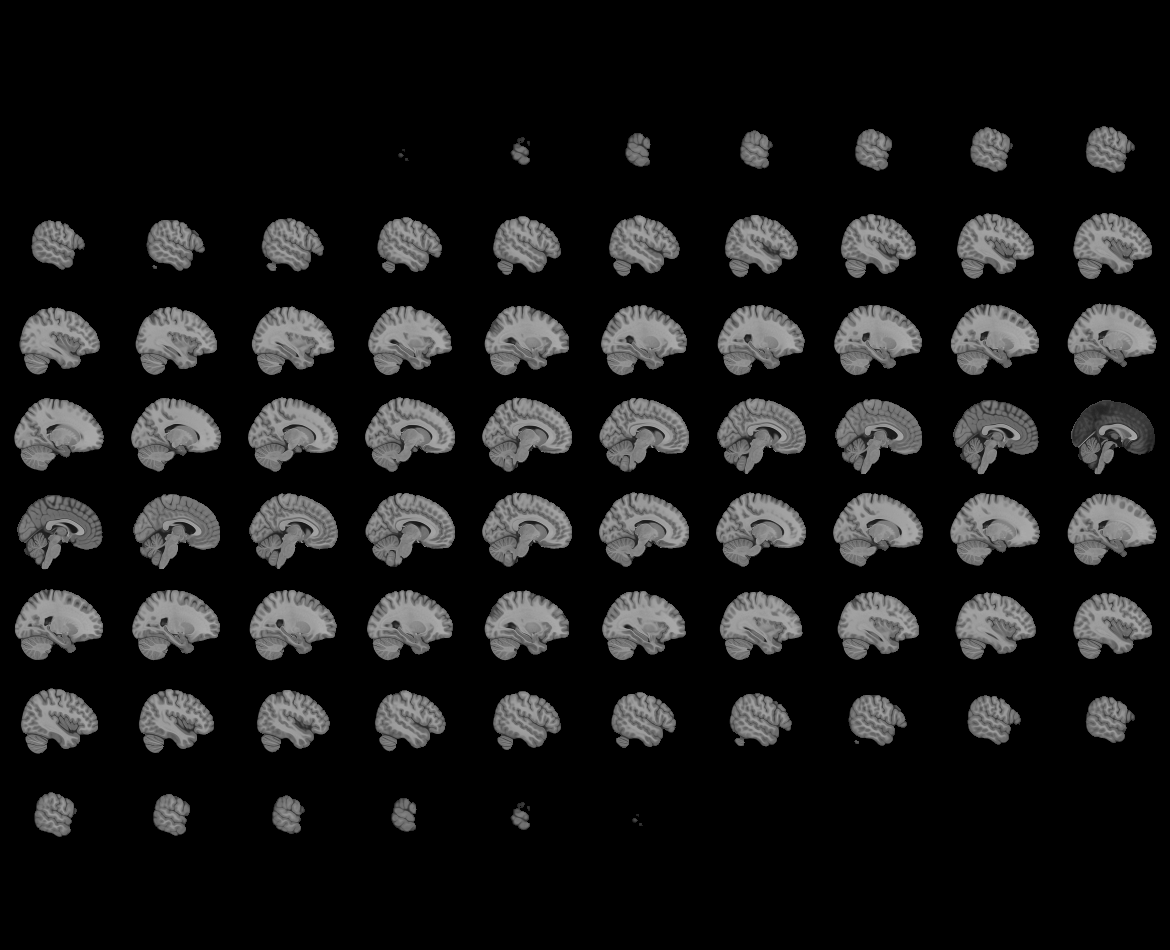
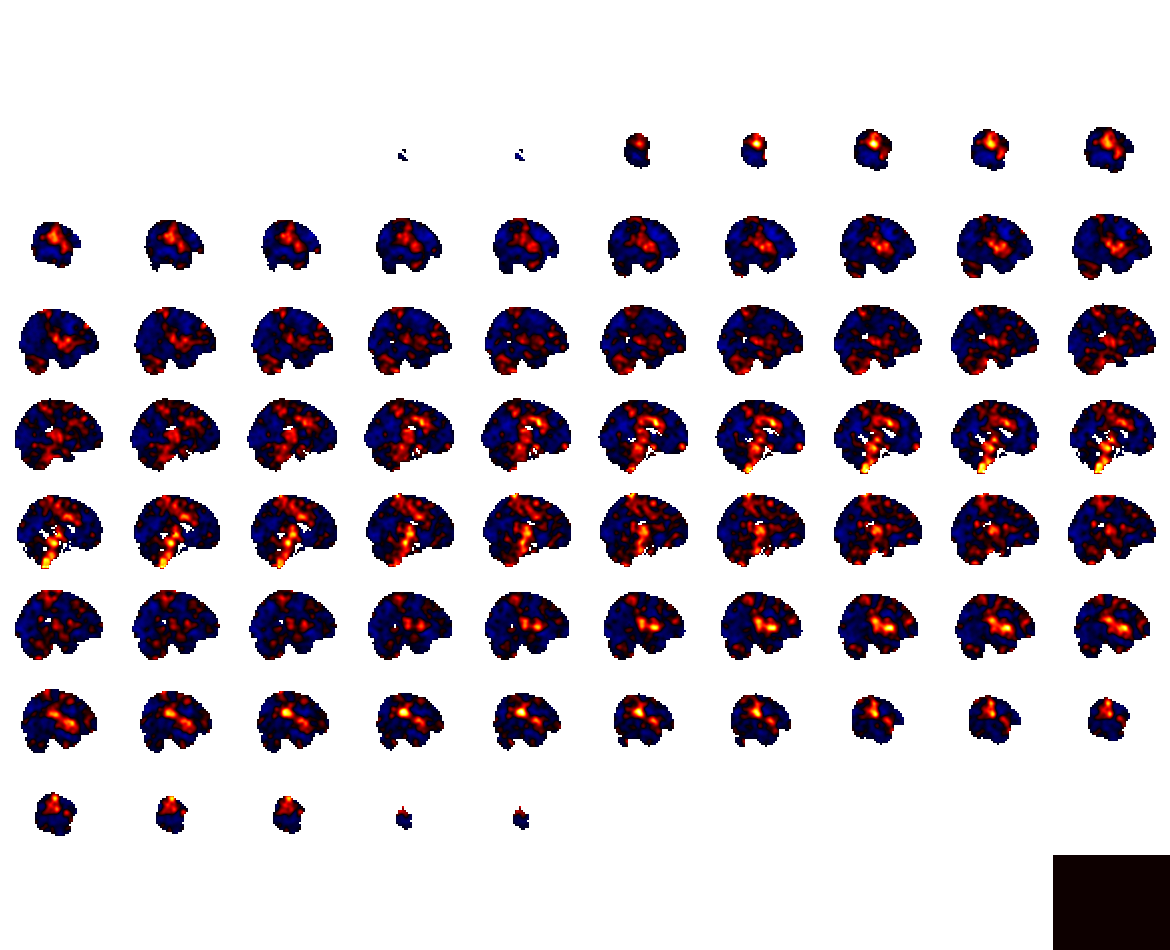

In [2]:
# the download function is a simple function to download a file from a url and save it to a temporary directory
file_path = "neuroquery/pain.nii.gz"

# load the map into memory
effect_map = load_img(file_path)

# plot the map interactively
view_img(effect_map)

## Neuronal cell type marker gene sets

NiSpace comes with some collections of gene sets, which are to be extended in the future.  
It's easy to add your own gene sets, but you can always ask to add a collection via a [GitHub issue](https://github.com/LeonDLotter/NiSpace/issues).

For comparison with the ABAnnotate example, we will use a cell type collection: "CellTypesPsychEncodeTPM".

In NiSpace, we call any grouping of predictor X maps a "collection". Collections can just be a list of maps to subset a larger dataset, or multiple sets of maps. Each map can additionally be associated with a weight.  
Collections are stored in the NiSpace data repository as text files. They can be loaded via the `fetch_collection` function, or directly with the actual region-wise data via the `fetch_reference` function.

Here, we take a look at the collection "CellTypesPsychEncodeTPM" from the "mrna" dataset.

If you want to provide your own collection, create a pandas table like the one below and pass it directly to the `collection` parameter.

In [3]:
from nispace.datasets import fetch_collection

fetch_collection("CellTypesPsychEncodeTPM", dataset="mrna")

INFO | 02/06/25 10:00:11 | nispace: Loading integrated collection 'CellTypesPsychEncodeTPM' for dataset 'mrna'.


,set,map
0,Adult-Ex1,CAMK2A
1,Adult-Ex1,CCDC88C
2,Adult-Ex1,CDH9
3,Adult-Ex1,DNM1
4,Adult-Ex1,GNAL
...,...,...
587,Adult-Oligo,RNASE1
588,Adult-Oligo,RRBP1
589,Adult-Oligo,TF
590,Adult-Oligo,TMEM144


With mRNA data from the Allen Human Brain Atlas (parcellation: Schaefer200MelbourneS2), this looks like:

In [4]:
from nispace.datasets import fetch_reference

fetch_reference("mrna", parcellation="Schaefer200", collection="CellTypesPsychEncodeTPM")

INFO | 02/06/25 10:00:11 | nispace: Loading mrna maps.
INFO | 02/06/25 10:00:12 | nispace: Applying collection filter from: /Users/llotter/nispace-data/reference/mrna/collection-CellTypesPsychEncodeTPM.collect.
INFO | 02/06/25 10:00:12 | nispace: Loading parcellated data: Schaefer200MelbourneS2
INFO | 02/06/25 10:00:12 | nispace: Keeping 200 cortical parcels.
The NiSpace "mRNA" dataset is based on Allen Human Brain Atlas (AHBA) gene expression data published in Hawrylycz et al., 
2012 (https://doi.org/10.1038/nature11405). The dataset consists of mRNA expression data from postmortem brain tissue of 
six donors, mapped onto MNI or fsaverage parcels using the abagen toolbox (Markello et al., 2021, https://doi.org/10.7554/eLife.72129).
The data was extracted using abagen.get_expression_data(..., lr_mirror="bidirectional"), considering parcel hemisphere and 
cortical vs. subcortical location. Only genes that showed a mean donor-to-donor Spearman correlation of > 0.2 were retained.
In addit

1_LH_CX_Vis_1  2_LH_CX_Vis_2  3_LH_CX_Vis_3  \
set         map                                                   
Adult-Ex1   CDH9         0.374633       0.258186       0.412824   
            GNAL         0.572302       0.470357       0.438357   
            GREB1L       0.522067       0.640355       0.633658   
            HPCAL1       0.425632       0.366374       0.393373   
            KCNK1        0.533008       0.323192       0.539986   
...                           ...            ...            ...   
Adult-Oligo GPNMB        0.244367       0.280275       0.472254   
            KCNMB4       0.421667       0.199524       0.434603   
            LGI3         0.507502       0.724270       0.581018   
            MBP          0.788937       0.720314       0.646906   
            NR4A2        0.436706       0.423665       0.461132   

                    4_LH_CX_Vis_4  5_LH_CX_Vis_5  6_LH_CX_Vis_6  \
set         map                                                   
Adult-Ex1   CDH9         0.123831       0.166423       0.491412   
            GNAL         0.532556       0.442742       0.533833   
            GREB1L       0.527616       0.698102       0.445616   
            HPCAL1       0.200699       0.240210       0.479332   
            KCNK1        0.172139       0.219367       0.672104   
...                           ...            ...            ...   
Adult-Oligo GPNMB        0.185904       0.318129       0.121552   
            KCNMB4       0.102821       0.131582       0.686218   
            LGI3         0.568349       0.740886       0.377247   
            MBP          0.855952       0.767628       0.560292   
            NR4A2        0.464074       0.399459       0.751153   

                    7_LH_CX_Vis_7  8_LH_CX_Vis_8  9_LH_CX_Vis_9  \
set         map                                                   
Adult-Ex1   CDH9         0.074009       0.413635       0.105713   
            GNAL         0.378738       0.410801       0.482617   
            GREB1L       0.598139       0.537377       0.633370   
            HPCAL1       0.178927       0.250646       0.160911   
            KCNK1        0.131694       0.469173       0.229310   
...                           ...            ...            ...   
Adult-Oligo GPNMB        0.170758       0.440333       0.208876   
            KCNMB4       0.065322       0.370687       0.076351   
            LGI3         0.710719       0.626916       0.597277   
            MBP          0.882258       0.710626       0.886554   
            NR4A2        0.452577       0.473266       0.431767   

                    10_LH_CX_Vis_10  ...  191_RH_CX_Default_PFCm_1  \
set         map                      ...                             
Adult-Ex1   CDH9           0.147665  ...                  0.732292   
            GNAL           0.491976  ...                  0.372124   
            GREB1L         0.597210  ...                  0.330418   
            HPCAL1         0.198703  ...                  0.836993   
            KCNK1          0.182699  ...                  0.465947   
...                             ...  ...                       ...   
Adult-Oligo GPNMB          0.147888  ...                  0.610765   
            KCNMB4         0.133956  ...                  0.739523   
            LGI3           0.617622  ...                  0.281273   
            MBP            0.890303  ...                  0.366306   
            NR4A2          0.468605  ...                  0.452252   

                    192_RH_CX_Default_PFCm_2  193_RH_CX_Default_PFCm_3  \
set         map                                                          
Adult-Ex1   CDH9                    0.795717                  0.515156   
            GNAL                    0.430402                  0.495466   
            GREB1L                  0.392200                  0.303657   
            HPCAL1                  0.902080                  0.624269   
            KCNK1                   0.523853     

## Run the analysis 

We will now run the analysis using a `workflow` function from NiSpace. Workflow functions run a complete analysis, from data loading to plotting, with a single function call.    
We can pass the collection name directly (so, the two cell blocks above are not needed).

In [5]:
# set some parameters
# put into a dictionary to pass to the following functions
kwargs = {
    "parcellation": "Schaefer200", # the parcellation to use, here, Schaefer200
    "x_collection": "CellTypesPsychEncodeTPM", # the collection to use, here, CellTypesPsychEncodeTPM
    "seed": 42, # the seed to use for the permutation analysis, for reproducibility
    "n_proc": 4, # number of parallel processes to use when possible
    "plot": False # dont plot, we will compare below
}

### Random sampling of gene sets

First, let's run a "classical" set enrichment analysis with random sampling of gene sets from the whole genome dataset 

In [6]:
from nispace.workflows import simple_xsea

colocalization_randomgenes, p_values_randomgenes, p_fdr_values_randomgenes, nispace_object_randomgenes = simple_xsea(
    y={"Pain": effect_map}, # our effect map, with the dictionary we can pass a name, can also be just the effect map
    x="mrna", # Allen Human Brain Atlas mRNA data extracted with the abagen package
    permute_sets=True, # permuting sets is not the default as you will see below, so we set it to True here
    **kwargs
)

INFO | 02/06/25 10:00:12 | nispace: Trying to fetch background X dataset.
INFO | 02/06/25 10:00:12 | nispace: Loading mrna maps.
INFO | 02/06/25 10:00:13 | nispace: Loading parcellated data: Schaefer200MelbourneS2
INFO | 02/06/25 10:00:13 | nispace: Keeping 200 cortical parcels.
INFO | 02/06/25 10:00:13 | nispace: Using integrated parcellation Schaefer200.
INFO | 02/06/25 10:00:13 | nispace: Loading integrated mrna dataset as X data.
INFO | 02/06/25 10:00:13 | nispace: Loading mrna maps.
INFO | 02/06/25 10:00:13 | nispace: Applying collection filter from: /Users/llotter/nispace-data/reference/mrna/collection-CellTypesPsychEncodeTPM.collect.
INFO | 02/06/25 10:00:13 | nispace: Loading parcellated data: Schaefer200MelbourneS2
INFO | 02/06/25 10:00:14 | nispace: Keeping 200 cortical parcels.
The NiSpace "mRNA" dataset is based on Allen Human Brain Atlas (AHBA) gene expression data published in Hawrylycz et al., 
2012 (https://doi.org/10.1038/nature11405). The dataset consists of mRNA expr

Parcellating (4 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 02/06/25 10:00:23 | nispace: Combined across images, 0 parcel(s) had only background intensity and were set to nan ([]).
INFO | 02/06/25 10:00:23 | nispace: Got 'y' data for 1 x 200 parcels.
INFO | 02/06/25 10:00:23 | nispace: Z-standardizing 'X' data.
INFO | 02/06/25 10:00:23 | nispace: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***
INFO | 02/06/25 10:00:23 | nispace: Running 'spearman' colocalization.
INFO | 02/06/25 10:00:23 | nispace: Will perform X-set enrichment analysis (XSEA).
INFO | 02/06/25 10:00:23 | nispace: Using 24 sets with between 2 and 32 samples. Aggregating within-set colocalizations with: mean.


Colocalizing (spearman, 4 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 02/06/25 10:00:31 | nispace: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 02/06/25 10:00:31 | nispace: Permutation of: X sets.
INFO | 02/06/25 10:00:31 | nispace: Loading observed colocalizations (method = 'spearman').
INFO | 02/06/25 10:00:31 | nispace: Generating permuted X sets.
INFO | 02/06/25 10:00:31 | nispace: Will use 5251 provided background maps.
INFO | 02/06/25 10:00:31 | nispace: Z-standardizing X background maps.


Permuting X set indices:   0%|          | 0/10000 [00:00<?, ?it/s]

Null colocalizations (spearman, 4 proc):   0%|          | 0/10000 [00:00<?, ?it/s]

INFO | 02/06/25 10:01:09 | nispace: Calculating exact p-values (tails = {'rho': 'two'}).
INFO | 02/06/25 10:01:09 | nispace: *** NiSpace.correct_p() - Correct p values for multiple comparisons. ***
INFO | 02/06/25 10:01:09 | nispace: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 
INFO | 02/06/25 10:01:09 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| spearman | sets         | True | None      | False | False       | False       | 
INFO | 02/06/25 10:01:09 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| spearman | sets         | True | fdrbh     | False | False       | False       | 


### Permutation of the input map

Now, let's run a set-enrichment analysis, but do not randomize the gene sets and rather "permute" the input map (not actually permutation but sampling of null maps with similar spatial structure). This is the default setting in NiSpace adopted from ABAnnotate and Fulcher's paper.

We supply additional arguments to tell `simple_xsea()` to not randomize genes but maps. Specifically, we randomize the input map ("Y", cf. the dependent variable): `permute_kwargs={"what": "maps", "maps_which": "Y"}`.


In [7]:
colocalization_randominput, p_values_randominput, p_fdr_values_randominput, nispace_object_randominput = simple_xsea(
    y={"Pain": effect_map}, # our effect map, with the dictionary we can pass a name, can also be just the effect map
    x="mrna", # Allen Human Brain Atlas mRNA data extracted with the abagen package
    **kwargs
)

INFO | 02/06/25 10:01:09 | nispace: Using integrated parcellation Schaefer200.
INFO | 02/06/25 10:01:09 | nispace: Loading integrated mrna dataset as X data.
INFO | 02/06/25 10:01:09 | nispace: Loading mrna maps.
INFO | 02/06/25 10:01:09 | nispace: Applying collection filter from: /Users/llotter/nispace-data/reference/mrna/collection-CellTypesPsychEncodeTPM.collect.
INFO | 02/06/25 10:01:09 | nispace: Loading parcellated data: Schaefer200MelbourneS2
INFO | 02/06/25 10:01:09 | nispace: Keeping 200 cortical parcels.
The NiSpace "mRNA" dataset is based on Allen Human Brain Atlas (AHBA) gene expression data published in Hawrylycz et al., 
2012 (https://doi.org/10.1038/nature11405). The dataset consists of mRNA expression data from postmortem brain tissue of 
six donors, mapped onto MNI or fsaverage parcels using the abagen toolbox (Markello et al., 2021, https://doi.org/10.7554/eLife.72129).
The data was extracted using abagen.get_expression_data(..., lr_mirror="bidirectional"), considerin

Parcellating (4 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 02/06/25 10:01:12 | nispace: Combined across images, 0 parcel(s) had only background intensity and were set to nan ([]).
INFO | 02/06/25 10:01:12 | nispace: Got 'y' data for 1 x 200 parcels.
INFO | 02/06/25 10:01:12 | nispace: Z-standardizing 'X' data.
INFO | 02/06/25 10:01:12 | nispace: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***
INFO | 02/06/25 10:01:12 | nispace: Running 'spearman' colocalization.
INFO | 02/06/25 10:01:12 | nispace: Will perform X-set enrichment analysis (XSEA).
INFO | 02/06/25 10:01:12 | nispace: Using 24 sets with between 2 and 32 samples. Aggregating within-set colocalizations with: mean.


Colocalizing (spearman, 4 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 02/06/25 10:01:12 | nispace: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 02/06/25 10:01:12 | nispace: Permutation of: Y maps.
INFO | 02/06/25 10:01:12 | nispace: Loading observed colocalizations (method = 'spearman').
INFO | 02/06/25 10:01:12 | nispace: Generating permuted Y maps.
INFO | 02/06/25 10:01:12 | nispace: No null maps found.
INFO | 02/06/25 10:01:12 | nispace: Generating null maps (n = 10000, null_method = 'moran').
INFO | 02/06/25 10:01:12 | nispace: Null map generation: Assuming n = 1 data vector(s) for n = 200 parcels.
INFO | 02/06/25 10:01:12 | nispace: Using provided distance matrix/matrices.
INFO | 02/06/25 10:01:12 | nispace: Generating null data separately for left and right hemisphere.


Moran null maps (4 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 02/06/25 10:01:12 | nispace: Left-to-right mirroring null maps (using left-to-right mapping).
INFO | 02/06/25 10:01:12 | nispace: Matching interhemispheric correlation. Observed correlation: 0.84


Mirroring null maps:   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 02/06/25 10:01:14 | nispace: Null data generation finished.
INFO | 02/06/25 10:01:14 | nispace: Running X Set Enrichment Analysis (XSEA) without set permutation.


Null colocalizations (spearman, 4 proc):   0%|          | 0/10000 [00:00<?, ?it/s]

INFO | 02/06/25 10:01:42 | nispace: Calculating exact p-values (tails = {'rho': 'two'}).
INFO | 02/06/25 10:01:42 | nispace: *** NiSpace.correct_p() - Correct p values for multiple comparisons. ***
INFO | 02/06/25 10:01:42 | nispace: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 
INFO | 02/06/25 10:01:42 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | None      | False | False       | False       | 
INFO | 02/06/25 10:01:42 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | fdrbh     | False | False       | False       | 


### Inspect the results

The workflow function returns dataframes with colocalization values, p values, and FDR-corrected p values. Let's take a look at the p values.

In [8]:
# Concatenate p values from both methods
p_values = pd.DataFrame(
    {
        "randomgenes": p_values_randomgenes.loc["Pain"],
        "randominput": p_values_randominput.loc["Pain"],
    }
)

# Display, sorted by the input map permutation results
p_values.sort_values(by="randominput")

,randomgenes,randominput
Adult-Ex8,0.0001,0.0260
Adult-OPC,0.0006,0.0324
Adult-Oligo,0.2944,0.0440
Dev-replicating,0.0142,0.0608
Adult-Micro,0.0004,0.0638
Adult-Ex3,0.0134,0.0702
Adult-Astro,0.0001,0.1006
Adult-Ex6,0.0001,0.1036
Adult-Endo,0.0650,0.1276
Adult-In8,0.5146,0.1714


What does this tell us? On first glance, we can see that both methods suggested "Adult-Ex8" as (one of the) the strongest associated cell type relative to null models.  
This matches the result from the ABAnnotate example and adds some face validity as Ex8 was defined as corticothalamic projection neurons in the [publication](https://doi.org/10.1126/science.aaf1204) associated with the cell type collection.

However, we can also see two more things:
1. The p values for the random gene set sampling are much lower than for the input null map method. This might indeed be an indication of inflated false positives! The initially cited paper by [Fulcher et al., 2021](https://doi.org/10.1038/s41467-021-22862-1) suggested this method to be affected by within-set coexpression patterns. The input null map method cannot have this problem, as the gene sets remain unchanged during the null runs.
2. The results seems much more conservative as compared to the [ABAnnotate example](https://github.com/LeonDLotter/ABAnnotate/blob/main/example/example_pain.md). As listed above, there are many implementation differences, and I would generally suggest to trust the much more advanced NiSpace implementation.

### Plot side by side

We have an integrated plotting method for the NiSpace objects that were returned by the workflow functions.

INFO | 02/06/25 10:01:42 | nispace: *** NiSpace.plot() - Plot colocalization results. ***
INFO | 02/06/25 10:01:43 | nispace: Creating categorical plot for method spearman, colocalization stat rho.
INFO | 02/06/25 10:01:44 | nispace: *** NiSpace.plot() - Plot colocalization results. ***
INFO | 02/06/25 10:01:45 | nispace: Creating categorical plot for method spearman, colocalization stat rho.


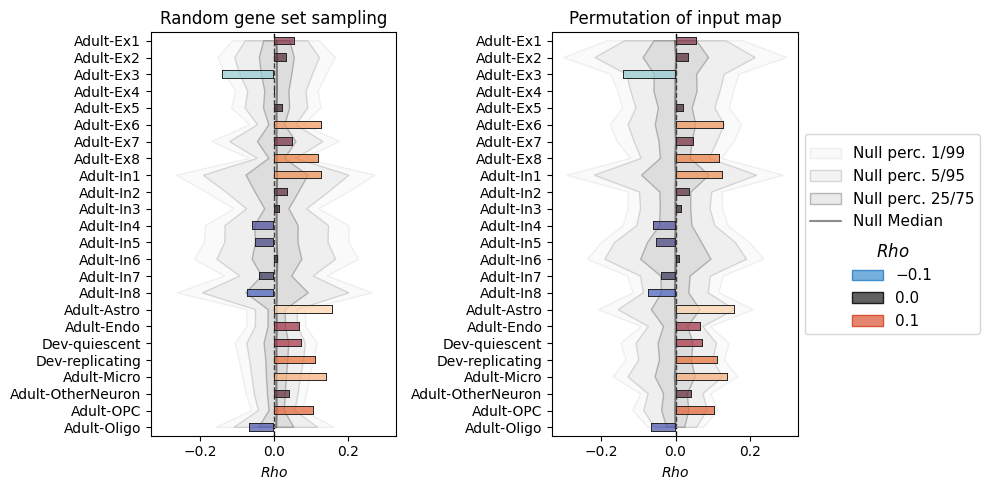

In [9]:
# create figure to host both plots
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True, sharex=True)

# plot both plots
nispace_object_randomgenes.plot(ax=axes[0], show=False, title="Random gene set sampling", fig=fig)
nispace_object_randominput.plot(ax=axes[1], show=False, title="Permutation of input map", fig=fig)

# hide legend of first plot
axes[0].legend_.set_visible(False)

# adjust layout
fig.tight_layout()

## Extra: Colocalization methods

An advantage of NiSpace is that it allows to flexibly use different colocalization methods. Above, we used Spearman's rho, but there are other options well suited for XSEA analysis.  
Good options are regression-based methods that reduce any number of predictors to one or more latent variables from which the dependent variable is then predicted.

We have partial least squares (`"pls"`) and principal component regression (`"pcr"`) as options.

Let's take a look at the results using PLS (default setting: n = 1 component).

In [10]:
colocalization_randomgenes_pls, p_values_randomgenes_pls, p_fdr_values_randomgenes_pls, _ = simple_xsea(
    y={"Pain": effect_map},
    x="mrna",
    colocalization_method="pls",
    permute_sets=True,
    **kwargs
)

INFO | 02/06/25 10:01:46 | nispace: Trying to fetch background X dataset.
INFO | 02/06/25 10:01:46 | nispace: Loading mrna maps.
INFO | 02/06/25 10:01:46 | nispace: Loading parcellated data: Schaefer200MelbourneS2
INFO | 02/06/25 10:01:46 | nispace: Keeping 200 cortical parcels.
INFO | 02/06/25 10:01:46 | nispace: Using integrated parcellation Schaefer200.
INFO | 02/06/25 10:01:46 | nispace: Loading integrated mrna dataset as X data.
INFO | 02/06/25 10:01:46 | nispace: Loading mrna maps.
INFO | 02/06/25 10:01:47 | nispace: Applying collection filter from: /Users/llotter/nispace-data/reference/mrna/collection-CellTypesPsychEncodeTPM.collect.
INFO | 02/06/25 10:01:47 | nispace: Loading parcellated data: Schaefer200MelbourneS2
INFO | 02/06/25 10:01:47 | nispace: Keeping 200 cortical parcels.
The NiSpace "mRNA" dataset is based on Allen Human Brain Atlas (AHBA) gene expression data published in Hawrylycz et al., 
2012 (https://doi.org/10.1038/nature11405). The dataset consists of mRNA expr

Parcellating (4 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 02/06/25 10:01:49 | nispace: Combined across images, 0 parcel(s) had only background intensity and were set to nan ([]).
INFO | 02/06/25 10:01:49 | nispace: Got 'y' data for 1 x 200 parcels.
INFO | 02/06/25 10:01:49 | nispace: Z-standardizing 'X' data.
INFO | 02/06/25 10:01:49 | nispace: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***
INFO | 02/06/25 10:01:49 | nispace: Running 'pls' colocalization.
INFO | 02/06/25 10:01:49 | nispace: Will perform X-set enrichment analysis (XSEA).
INFO | 02/06/25 10:01:49 | nispace: Using 24 sets with between 2 and 32 samples. Aggregating within-set colocalizations with: mean.


Colocalizing (pls, 4 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 02/06/25 10:01:49 | nispace: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 02/06/25 10:01:49 | nispace: Permutation of: X sets.
INFO | 02/06/25 10:01:49 | nispace: Loading observed colocalizations (method = 'pls').
INFO | 02/06/25 10:01:49 | nispace: Generating permuted X sets.
INFO | 02/06/25 10:01:49 | nispace: Will use 5251 provided background maps.
INFO | 02/06/25 10:01:49 | nispace: Z-standardizing X background maps.


Permuting X set indices:   0%|          | 0/10000 [00:00<?, ?it/s]

Null colocalizations (pls, 4 proc):   0%|          | 0/10000 [00:00<?, ?it/s]

INFO | 02/06/25 10:02:57 | nispace: Calculating exact p-values (tails = {'r2': 'upper', 'beta': 'two'}).
INFO | 02/06/25 10:02:58 | nispace: *** NiSpace.correct_p() - Correct p values for multiple comparisons. ***
INFO | 02/06/25 10:02:58 | nispace: Returning colocalizations: 
| METHOD | XSEA | X_REDUCTION | Y_TRANSFORM | 
| pls    | True | False       | False       | 
INFO | 02/06/25 10:02:58 | nispace: Returning p values: 
| METHOD | PERMUTE_WHAT | XSEA | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| pls    | sets         | True | None      | False | False       | False       | 
INFO | 02/06/25 10:02:58 | nispace: Returning p values: 
| METHOD | PERMUTE_WHAT | XSEA | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| pls    | sets         | True | fdrbh     | False | False       | False       | 


Looking at the p values, we can see that the results are more conservative as compared to the Spearman's rho results, even though we used the gene permutation null model! This requires further testing, but could be due to completely different consideration of within-set correlations.  
Regression-based methods return stats as dictionaries, here with a "beta" and "r2" key.

In [11]:
p_values_randomgenes_pls["beta"].loc["Pain"].sort_values()

Adult-Ex8            0.0004
Adult-Astro          0.0046
Adult-Ex6            0.0054
Dev-replicating      0.0132
Adult-OPC            0.0142
Adult-Endo           0.0406
Dev-quiescent        0.0468
Adult-Micro          0.0618
Adult-Ex3            0.1088
Adult-Ex1            0.1400
Adult-OtherNeuron    0.2022
Adult-In8            0.2480
Adult-In7            0.3300
Adult-In1            0.4300
Adult-Ex5            0.4528
Adult-Ex4            0.6216
Adult-Oligo          0.6288
Adult-In6            0.6542
Adult-In3            0.6874
Adult-In4            0.7250
Adult-In5            0.8364
Adult-In2            0.8612
Adult-Ex7            0.8902
Adult-Ex2            0.9154
Name: Pain, dtype: float32

## Extra: Other mRNA expression dataset

Here's the same analysis but using Allen Brain Atlas based gene expression data reconstructed by [Wagstyl et al., 2024](https://doi.org/10.7554/eLife.86933.3).  
We get much more genes with this dataset because across-ABA-donor reproducibility was quantified in a different fashion and turned out somewhat higher.

In [14]:
colocalization_randomgenes_plsmagicc, p_values_randomgenes_plsmagicc, p_fdr_values_randomgenes_plsmagicc, _ = simple_xsea(
    y={"Pain": effect_map},
    x="magicc",
    colocalization_method="pls",
    permute_sets=True,
    **kwargs
)

INFO | 02/06/25 10:06:28 | nispace: Trying to fetch background X dataset.
INFO | 02/06/25 10:06:28 | nispace: Loading magicc maps.
INFO | 02/06/25 10:06:29 | nispace: Loading parcellated data: Schaefer200MelbourneS2
INFO | 02/06/25 10:06:29 | nispace: Keeping 200 cortical parcels.
INFO | 02/06/25 10:06:29 | nispace: Using integrated parcellation Schaefer200.
INFO | 02/06/25 10:06:29 | nispace: Loading integrated magicc dataset as X data.
INFO | 02/06/25 10:06:29 | nispace: Loading magicc maps.
INFO | 02/06/25 10:06:30 | nispace: Applying collection filter from: /Users/llotter/nispace-data/reference/magicc/collection-CellTypesPsychEncodeTPM.collect.
INFO | 02/06/25 10:06:32 | nispace: Loading parcellated data: Schaefer200MelbourneS2
INFO | 02/06/25 10:06:33 | nispace: Keeping 200 cortical parcels.
The NiSpace "magicc" dataset is based on Allen Human Brain Atlas (AHBA) gene expression data published in Hawrylycz et al., 
2012 (https://doi.org/10.1038/nature11405). The dataset consists of

Parcellating (4 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 02/06/25 10:06:37 | nispace: Combined across images, 0 parcel(s) had only background intensity and were set to nan ([]).
INFO | 02/06/25 10:06:37 | nispace: Got 'y' data for 1 x 200 parcels.
INFO | 02/06/25 10:06:37 | nispace: Z-standardizing 'X' data.
INFO | 02/06/25 10:06:37 | nispace: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***
INFO | 02/06/25 10:06:37 | nispace: Running 'pls' colocalization.
INFO | 02/06/25 10:06:37 | nispace: Will perform X-set enrichment analysis (XSEA).
INFO | 02/06/25 10:06:37 | nispace: Using 24 sets with between 2 and 51 samples. Aggregating within-set colocalizations with: mean.


Colocalizing (pls, 4 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 02/06/25 10:06:38 | nispace: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 02/06/25 10:06:38 | nispace: Permutation of: X sets.
INFO | 02/06/25 10:06:38 | nispace: Loading observed colocalizations (method = 'pls').
INFO | 02/06/25 10:06:38 | nispace: Generating permuted X sets.
INFO | 02/06/25 10:06:38 | nispace: Will use 11146 provided background maps.
INFO | 02/06/25 10:06:38 | nispace: Z-standardizing X background maps.


Permuting X set indices:   0%|          | 0/10000 [00:00<?, ?it/s]

Null colocalizations (pls, 4 proc):   0%|          | 0/10000 [00:00<?, ?it/s]

INFO | 02/06/25 10:08:18 | nispace: Calculating exact p-values (tails = {'r2': 'upper', 'beta': 'two'}).
INFO | 02/06/25 10:08:19 | nispace: *** NiSpace.correct_p() - Correct p values for multiple comparisons. ***
INFO | 02/06/25 10:08:19 | nispace: Returning colocalizations: 
| METHOD | XSEA | X_REDUCTION | Y_TRANSFORM | 
| pls    | True | False       | False       | 
INFO | 02/06/25 10:08:19 | nispace: Returning p values: 
| METHOD | PERMUTE_WHAT | XSEA | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| pls    | sets         | True | None      | False | False       | False       | 
INFO | 02/06/25 10:08:19 | nispace: Returning p values: 
| METHOD | PERMUTE_WHAT | XSEA | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| pls    | sets         | True | fdrbh     | False | False       | False       | 


Similar results reassure us of the robustness of our results.

In [16]:
p_values_randomgenes_plsmagicc["beta"].loc["Pain"].sort_values()

Adult-Ex8            0.0002
Adult-Endo           0.0112
Dev-replicating      0.0206
Adult-Ex6            0.0282
Adult-Ex3            0.0426
Adult-Oligo          0.0724
Adult-Ex4            0.0944
Adult-Astro          0.1180
Adult-In7            0.2028
Adult-In4            0.2090
Adult-Ex5            0.3130
Adult-OtherNeuron    0.3234
Adult-OPC            0.3512
Adult-In5            0.3516
Adult-In6            0.4758
Adult-Micro          0.5584
Adult-In1            0.6102
Dev-quiescent        0.6236
Adult-In3            0.6920
Adult-Ex1            0.7434
Adult-Ex7            0.7938
Adult-In8            0.8224
Adult-Ex2            0.9034
Adult-In2            0.9100
Name: Pain, dtype: float32